# Opcion B - Deteccion de Ciberacoso en Redes Sociales

Notebook alineado con los requisitos del PDF del proyecto:
- Preprocesamiento NLP
- Vectorizacion BoW y TF-IDF
- Comparacion de al menos 3 modelos
- Tuning de hiperparametros con validacion cruzada
- Matrices de confusion y pruebas de usuario


## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '../src')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from text_preprocessing import TextPreprocessor
from vectorization import vectorize_texts
from models import create_models

sns.set_theme(style='whitegrid')
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rjbar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rjbar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Load and Explore the Dataset

Shape: (47692, 2)
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying

Valores faltantes:
tweet_text            0
cyberbullying_type    0
dtype: int64

Distribucion de clases:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


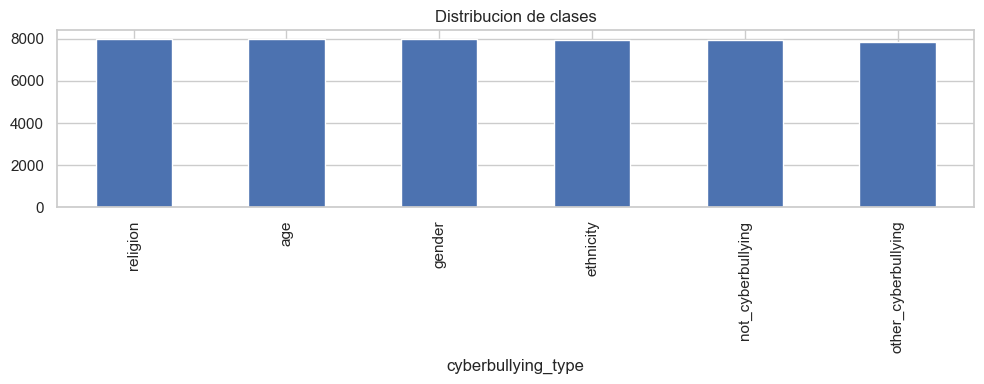

In [2]:
DATA_PATH = '../data/raw/cyberbullying_tweets.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df.head(3))

print('\nValores faltantes:')
print(df.isna().sum())

print('\nDistribucion de clases:')
print(df['cyberbullying_type'].value_counts())

plt.figure(figsize=(10, 4))
df['cyberbullying_type'].value_counts().plot(kind='bar')
plt.title('Distribucion de clases')
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Preprocessing

In [3]:
df = df.dropna(subset=['tweet_text', 'cyberbullying_type']).copy()

pre = TextPreprocessor()
df['tweet_text_cleaned'] = df['tweet_text'].apply(pre.process_text)

print(df[['tweet_text', 'tweet_text_cleaned']].head(5))

                                          tweet_text  \
0  In other words #katandandre, your food was cra...   
1  Why is #aussietv so white? #MKR #theblock #ImA...   
2  @XochitlSuckkks a classy whore? Or more red ve...   
3  @Jason_Gio meh. :P  thanks for the heads up, b...   
4  @RudhoeEnglish This is an ISIS account pretend...   

                                  tweet_text_cleaned  
0                             word food crapilicious  
1                                              white  
2                    classy whore red velvet cupcake  
3  meh p thanks head concerned another angry dude...  
4  isi account pretending kurdish account like is...  


## 4. Text Normalization and Tokenization

La normalizacion, tokenizacion y lematizacion se aplicaron dentro de TextPreprocessor.

In [4]:
sample = df['tweet_text'].iloc[0]
print('Original:', sample)
print('Procesado:', pre.process_text(sample))

Original: In other words #katandandre, your food was crapilicious! #mkr
Procesado: word food crapilicious


## 5. Text Vectorization (Bag of Words and TF-IDF)

In [5]:
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_bow = bow_vec.fit_transform(df['tweet_text_cleaned'])
X_tfidf_full = tfidf_vec.fit_transform(df['tweet_text_cleaned'])

print('BoW shape:', X_bow.shape)
print('TF-IDF shape:', X_tfidf_full.shape)

BoW shape: (47692, 5000)
TF-IDF shape: (47692, 5000)


## 6. Train-Test Split

In [6]:
label_map = {c: i for i, c in enumerate(sorted(df['cyberbullying_type'].unique()))}
inv_label_map = {v: k for k, v in label_map.items()}
y = df['cyberbullying_type'].map(label_map)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['tweet_text_cleaned'], y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_test, tfidf_model = vectorize_texts(X_train_text, X_test_text, vectorizer_type='tfidf', max_features=5000)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (38153, 5000) Test: (9539, 5000)


## 7. Model 1: Naive Bayes Classifier

In [7]:
models = create_models(seed=42)
nb = models['Naive Bayes']
nb.train(X_train, y_train)
nb_metrics = nb.evaluate(X_test, y_test)
print(nb_metrics)

{'accuracy': 0.7567879232623965, 'precision': 0.7492560010151461, 'recall': 0.7567879232623965, 'f1': 0.7478076361370286}


## 8. Model 2: Logistic Regression (tuned)

In [8]:
lr_grid = {
    'C': [0.5, 1.0, 2.0],
    'class_weight': [None, 'balanced']
}

lr_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)
lr = lr_search.best_estimator_
lr_pred = lr.predict(X_test)

lr_metrics = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_test, lr_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_test, lr_pred, average='weighted', zero_division=0),
}

print('Best CV F1 (weighted):', lr_search.best_score_)
print('Best params:', lr_search.best_params_)
print(lr_metrics)

Best CV F1 (weighted): 0.8121982363121738
Best params: {'C': 1.0, 'class_weight': 'balanced'}
{'accuracy': 0.8113009749449628, 'precision': 0.8165809361323711, 'recall': 0.8113009749449628, 'f1': 0.8134153024086033}


## 9. Model 3: Gradient Boosting (Ensamble)

Para cumplir la familia de ensambles pedida en el PDF, usamos Gradient Boosting con ajuste de hiperparametros por validacion cruzada.

In [9]:
gb_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)
gb = gb_search.best_estimator_
gb_pred = gb.predict(X_test)

gb_metrics = {
    'accuracy': accuracy_score(y_test, gb_pred),
    'precision': precision_score(y_test, gb_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_test, gb_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_test, gb_pred, average='weighted', zero_division=0),
}

print('Best CV F1 (weighted):', gb_search.best_score_)
print('Best params:', gb_search.best_params_)
print(gb_metrics)

Best CV F1 (weighted): 0.8085063078660689
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
{'accuracy': 0.8124541356536324, 'precision': 0.8291362986827652, 'recall': 0.8124541356536324, 'f1': 0.8101192611187492}


## 10. Model Comparison and Evaluation

In [10]:
comparison = pd.DataFrame([
    {'Model': 'Naive Bayes', **nb_metrics},
    {'Model': 'Logistic Regression (tuned)', **lr_metrics},
    {'Model': 'Gradient Boosting (tuned)', **gb_metrics},
])
comparison = comparison[['Model', 'accuracy', 'precision', 'recall', 'f1']].sort_values('f1', ascending=False)
comparison

,Model,accuracy,precision,recall,f1
1,Logistic Regression (tuned),0.811301,0.816581,0.811301,0.813415
2,Gradient Boosting (tuned),0.812454,0.829136,0.812454,0.810119
0,Naive Bayes,0.756788,0.749256,0.756788,0.747808


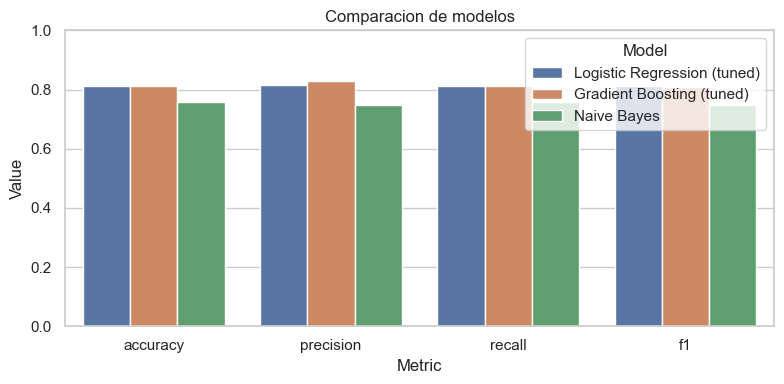

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison.melt(id_vars='Model', var_name='Metric', value_name='Value'), x='Metric', y='Value', hue='Model')
plt.ylim(0, 1)
plt.title('Comparacion de modelos')
plt.tight_layout()
plt.show()

## 11. Confusion Matrix and Classification Metrics

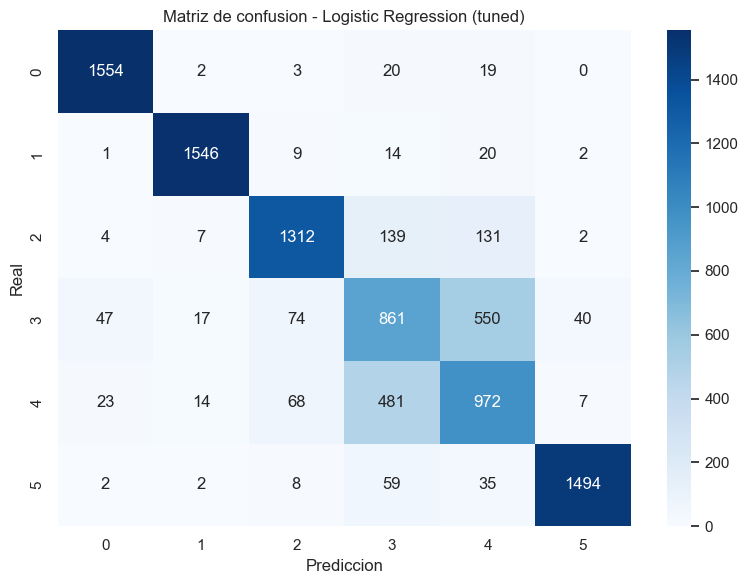

                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1598
          ethnicity       0.97      0.97      0.97      1592
             gender       0.89      0.82      0.86      1595
  not_cyberbullying       0.55      0.54      0.54      1589
other_cyberbullying       0.56      0.62      0.59      1565
           religion       0.97      0.93      0.95      1600

           accuracy                           0.81      9539
          macro avg       0.82      0.81      0.81      9539
       weighted avg       0.82      0.81      0.81      9539



In [12]:
best_name = comparison.iloc[0]['Model']
best = {
    'Naive Bayes': nb,
    'Logistic Regression (tuned)': lr,
    'Gradient Boosting (tuned)': gb,
}[best_name]

y_pred = best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusion - {best_name}')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=[inv_label_map[i] for i in range(len(inv_label_map))]))

In [13]:
ok_idx = np.where(y_pred == y_test.values)[0][:3]
fail_idx = np.where(y_pred != y_test.values)[0][:3]

print('Ejemplos bien clasificados:')
for i in ok_idx:
    print('-', X_test_text.iloc[i][:120], '=>', inv_label_map[y_pred[i]])

print('\nEjemplos mal clasificados:')
for i in fail_idx:
    print('-', X_test_text.iloc[i][:120], '=> pred:', inv_label_map[y_pred[i]], '| real:', inv_label_map[y_test.values[i]])

Ejemplos bien clasificados:
- idiotdeath time anyone die tomorrow idiot hatred muslim northerner crystal clear rejoice deathno wonder u r always desce => religion
- futhermore islam based theft mohammed raised army giving 45 everything stole => religion
- stating must condemn christian belief support radical overthrow constitutional republic democrat changed gave returned e => religion

Ejemplos mal clasificados:
- rt anti stop treating block trophy soon feminist stop treating block argument => pred: other_cyberbullying | real: gender
- rt idgaf shorty wear cause nigga look buh cant finna stop ha looking bad asl => pred: not_cyberbullying | real: ethnicity
- could benign hilarity situation lost => pred: other_cyberbullying | real: not_cyberbullying


## 12. User Testing Function

In [14]:
def predict_tweet(tweet: str):
    cleaned = pre.process_text(tweet)
    x = tfidf_model.transform([cleaned])
    pred = best.predict(x)[0]
    return inv_label_map[pred], cleaned

samples = [
    "I hope you have a great day!",
    "You are stupid and nobody wants you",
    "Go back to your country, we don't want you here",
]

for s in samples:
    label, cleaned = predict_tweet(s)
    print('Tweet:', s)
    print('Cleaned:', cleaned)
    print('Prediction:', label)
    print('-' * 60)

Tweet: I hope you have a great day!
Cleaned: hope great day
Prediction: not_cyberbullying
------------------------------------------------------------
Tweet: You are stupid and nobody wants you
Cleaned: stupid nobody want
Prediction: other_cyberbullying
------------------------------------------------------------
Tweet: Go back to your country, we don't want you here
Cleaned: go back country dont want
Prediction: not_cyberbullying
------------------------------------------------------------


### Conclusiones

- Se cumplieron los pasos requeridos por el proyecto Opcion B.
- Se compararon 3 modelos de familias diferentes y se aplico tuning con validacion cruzada para 2 de ellos.
- El notebook queda alineado con la corrida reproducible del script principal.